In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

### Load TLGRF Benchmark Dataset

In [2]:
benchmark_TLGRF_dataset = dd.read_csv("../generate_benchmark_TLGRF_dataset/benchmark_TLGRF_dataset.csv", assume_missing=True).compute()
benchmark_TLGRF_dataset["datetime"] = pd.to_datetime(benchmark_TLGRF_dataset["datetime"])

df = benchmark_TLGRF_dataset.copy()
fips_list = df["fips"].unique()
display(benchmark_TLGRF_dataset)

,fips,county,state,days_from_start,datetime,intercept_TLGRF,r_TLGRF,log_rolled_cases,TLGRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001.0,Autauga,Alabama,87.0,2020-04-17,-26.766326,0.028066,3.030824,3.227285,3.122994
1,1001.0,Autauga,Alabama,88.0,2020-04-18,-313.778047,0.007752,3.030824,3.085088,3.160035
2,1001.0,Autauga,Alabama,89.0,2020-04-19,-60.990643,0.021119,3.044522,3.192355,3.183989
3,1001.0,Autauga,Alabama,90.0,2020-04-20,-54.020959,0.022045,3.064725,3.219041,3.213145
4,1001.0,Autauga,Alabama,91.0,2020-04-21,-216.383634,0.010171,3.064725,3.135925,3.241476
...,...,...,...,...,...,...,...,...,...,...
82775,99999.0,New York City,New York,1153.0,2023-03-19,1456.032249,-0.030986,9.544831,9.327926,NaN
82776,99999.0,New York City,New York,1154.0,2023-03-20,1389.214236,-0.039535,9.496840,9.220095,NaN
82777,99999.0,New York City,New York,1155.0,2023-03-21,1323.021840,-0.054503,9.430176,9.048656,NaN
82778,99999.0,New York City,New York,1156.0,2023-03-22,1531.624962,-0.024711,9.405484,9.232510,NaN


### Load Classical GRF Backtests

In [3]:
directory = "./classical_grf_results/classical_grf_backtest_state_forests_windowsize=2"
file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
def read_csv_file(file_path):
        # Read the CSV file into a pandas DataFrame
        GRF_df = pd.read_csv(file_path)
        # Update the progress bar
        return GRF_df

with tqdm(total=len(file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in file_paths)
    pbar.update(len(file_paths))  # Manually update the progress bar

# Close the progress bar
pbar.close()



In [4]:
GRF_results = pd.concat(GRF_dfs).sort_values(by=["fips", "days_from_start"])
GRF_results["datetime"] = pd.to_datetime(GRF_results["datetime"])
GRF_results = GRF_results.dropna(subset=["predicted.grf.future.last"])
GRF_results = GRF_results.rename(columns={"log_rolled_cases.x": "log_rolled_cases", "t0.hat":"intercept_GRF", "tau.hat":"r_GRF", "predicted.grf.future.last":"GRF_predicted_log_rolled_cases"})
GRF_results["shifted_log_rolled_cases"] = GRF_results.groupby("fips")["log_rolled_cases"].shift(-7)
GRF_results = GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(GRF_results)

,fips,county,state,days_from_start,datetime,log_rolled_cases,intercept_GRF,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,Autauga,Alabama,87,2020-04-17,3.030824,-19.697036,0.030017,3.240941,3.122994
0,1001,Autauga,Alabama,88,2020-04-18,3.030824,-451.323199,0.005757,3.071119,3.160035
0,1001,Autauga,Alabama,89,2020-04-19,3.044522,-43.747908,0.023970,3.212309,3.183989
0,1001,Autauga,Alabama,90,2020-04-20,3.064725,-45.916735,0.023410,3.228593,3.213145
0,1001,Autauga,Alabama,91,2020-04-21,3.064725,-119.613893,0.014959,3.169435,3.241476
...,...,...,...,...,...,...,...,...,...,...
2222,99999,New York City,New York,1153,2023-03-19,9.544831,1492.050933,-0.027742,9.350634,NaN
2212,99999,New York City,New York,1154,2023-03-20,9.496840,1457.023852,-0.030832,9.281019,NaN
2194,99999,New York City,New York,1155,2023-03-21,9.430176,1369.632744,-0.042936,9.129623,NaN
2190,99999,New York City,New York,1156,2023-03-22,9.405484,1538.261887,-0.024287,9.235474,NaN


### Compute RMSE and MAE

In [5]:
GRF_results["GRF_predicted_log_rolled_cases"].isna().sum()

0

In [6]:
rmse_GRF_func = lambda x: np.sqrt(np.nanmean((x["GRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_GRF_func = lambda x: np.nanmean(np.abs(x["GRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
#

log_20 = np.log(20)

TLGRF_df = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["datetime"] <= "2022-12-31"]
TLGRF_df = TLGRF_df[TLGRF_df["log_rolled_cases"] >= log_20]
#TLGRF_df = TLGRF_df[TLGRF_df["datetime"] >= "2020-06-01"]

GRF_df = GRF_results[GRF_results["datetime"] <= "2022-12-31"]
GRF_df = GRF_df[GRF_df["log_rolled_cases"] >= log_20]
#GRF_df = GRF_df[GRF_df["datetime"] >= "2020-06-01"]


#TLGRF
RMSE_TLGRF = TLGRF_df.groupby("datetime").apply(rmse_TLGRF_func)
MAE_TLGRF = TLGRF_df.groupby("datetime").apply(mae_TLGRF_func)
#GRF
RMSE_GRF = GRF_df.groupby("datetime").apply(rmse_GRF_func)
MAE_GRF = GRF_df.groupby("datetime").apply(mae_GRF_func)

In [7]:
metrics_comparison_df = pd.DataFrame()

metrics_comparison_df["RMSE"] = [RMSE_GRF.median(), RMSE_TLGRF.median()]
metrics_comparison_df["MAE"] = [MAE_GRF.median(), MAE_TLGRF.median()]
metrics_comparison_df.index = ["GRF", "TLGRF"]
metrics_comparison_df

,RMSE,MAE
GRF,0.200509,0.128161
TLGRF,0.208981,0.132172


In [8]:
[RMSE_GRF.median(), RMSE_TLGRF.median()]

[0.20050877369182948, 0.20898140701665346]

In [9]:
[MAE_GRF.median(), MAE_TLGRF.median()]

[0.12816135113280458, 0.13217198514168724]

### Plot TLGRF vs GRF

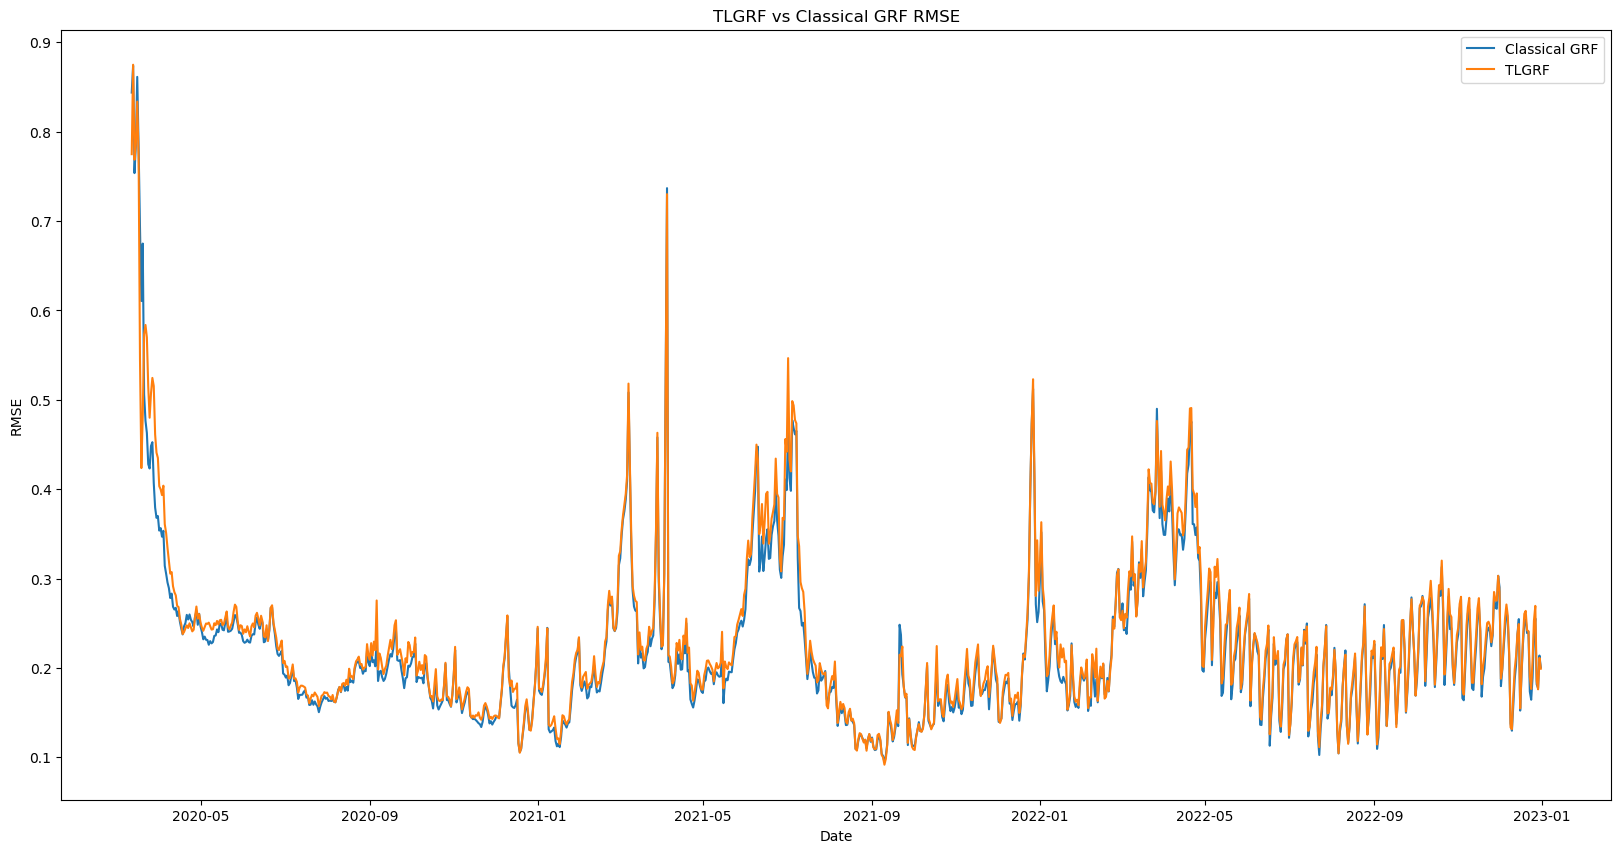

In [10]:
plt.figure(figsize=(20,10))

plt.plot(RMSE_GRF, label="Classical GRF")
plt.plot(RMSE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("TLGRF vs Classical GRF RMSE")
plt.show()

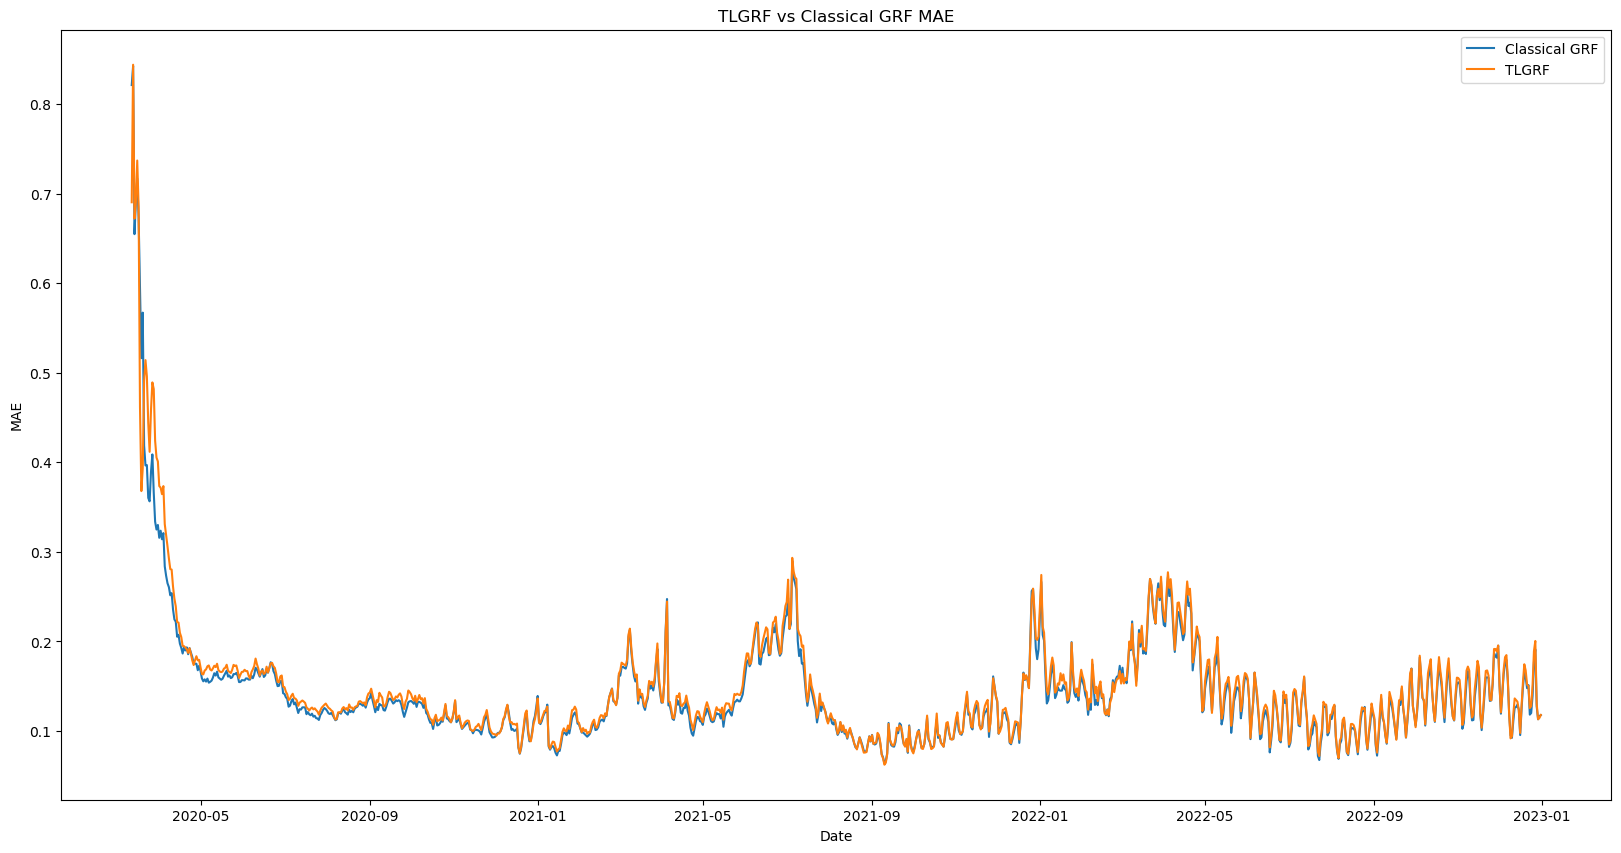

In [11]:
plt.figure(figsize=(20,10))

plt.plot(MAE_GRF, label="Classical GRF")
plt.plot(MAE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("TLGRF vs Classical GRF MAE")
plt.show()

In [12]:
log_20 = np.log(20)
(TLGRF_df["log_rolled_cases"] <= log_20).sum()

0

In [13]:
(GRF_df["log_rolled_cases"] <= log_20).sum()

0